# All-year `model_df` merge (2020–2023)

Builds a **person–year** modeling table for each MEPS year (same construction as `2023_clean.ipynb` `model_df`), writes each year out, then stacks them into one panel.

**Grain after merge:** one row per `(DUPERSID, YEAR)` — not one row per person across the whole panel.
#the model is going to duplicate user id - everything is duplicated

## Design decisions & assumptions

### 1. Years are built independently, then stacked

Each year runs the same adherence pipeline (`clean_meps.build`) with **that year’s** Rx file, CLNK, conditions, and person file.

| Piece | Scope |
|---|---|
| Numerator (`total_valid_days`) | Sum of `RXDAYSUP` for fills **in that calendar year**, capped at `min(365, total_days_supply)` |
| Denominator (`total_days_supply`) | Person’s PSTATS-eligible days **in that year**, further clamped by drug-start days **in that year** |
| `meps_adherence_ratio` | `100 * numerator / denominator` for that year only |

We do **not** invent a multi-year denominator (e.g. 1460 days) or average ratios across years before stacking.

### 2. Same patient in more than one year

**Assumption:** MEPS `DUPERSID` is stable for a person across years they remain in the survey. A person present in 2021 and 2022 contributes **two rows** in the merged panel:

- `(DUPERSID=X, YEAR=2021)` with 2021 fills / 2021 PSTATS window / 2021 demographics
- `(DUPERSID=X, YEAR=2022)` with 2022 fills / 2022 PSTATS window / 2022 demographics

Demographics (`AGE`, insurance, poverty, delay flags) are **year-specific** (taken from that year’s person file). They are allowed to change across rows for the same `DUPERSID`.

### 3. Denominator when a drug starts mid-year (or between rounds)

Within a year, denominator is:

```text
total_days_supply = min(person_PSTATS_days_in_year, drug_start_days)
```

`drug_start_days` (from earliest fill’s `RXBEGYRX` / `RXBEGMM`):

| Drug start | `drug_start_days` |
|---|---|
| Before this calendar year | **365** (drug considered active all year; PSTATS may still shrink the window) |
| This year, month 1–12 known | Days from **1st of that month → Dec 31** |
| This year, month missing / sentinel | **365** (conservative — do not invent a start month) |
| Start year missing or after this year | **365** (conservative) |

**Between years:** if a patient starts a drug in Nov 2021, then:

- **2021 row:** short `drug_start_days` (~61 days from Nov 1), so adherence is not punished for “missing” Jan–Oct.
- **2022 row:** `RXBEGYRX < 2022` → `drug_start_days = 365`; denominator is the **2022** PSTATS window only. 2021 fills never enter the 2022 numerator.

**Between rounds inside a year:** PSTATS / BEGRF / ENDRF already define the person’s eligible window for that year (joiners, leavers, R5/3 nonresponse). Drug-start clamp is applied **on top of** that window. We do not re-open eligibility across year boundaries.

### 4. What we intentionally do *not* do

- No carry-forward of unused days-supply from Dec Year N into Year N+1.
- No pooled 2020–2023 MPR with a single long denominator.
- No collapsing multi-year patients into one row (that would mix incompatible denominators).
- Drug one-hots use **`RXDRGNAME`** (MEPS `RXDRGNAM`; sentinel codes fall back to `RXNAME`), not brand-level `RXNAME`. `RXDRG_*` / `ICD_*` one-hots are built **per year**, then column-aligned on merge (`fillna(0)` for drugs/conditions unseen in a year).

### 5. Outputs

| Path | Contents |
|---|---|
| `Notebooks/MEPS/output/{year}/tables/model_df_pair.parquet` | Drug–condition pair rows + demos (pre RX/ICD one-hot) |
| `Notebooks/MEPS/output/{year}/tables/model_df.parquet` | Patient–year rows (post one-hot) |
| `Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet` | Stacked patient–year panel |


In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

# Repo layout: Notebooks/allYearMergeClean.ipynb → repo root has app/ and data/
REPO = Path("..").resolve()
if not (REPO / "app" / "clean_meps.py").exists():
    REPO = Path.cwd().resolve()
    if not (REPO / "app" / "clean_meps.py").exists():
        REPO = Path.cwd().resolve().parent

sys.path.insert(0, str(REPO / "app"))

from clean_meps import (  # noqa: E402
    YEAR_FILES,
    all_years_output_dirs,
    build,
    output_dirs,
    resolve_meps_dir,
)

MEPS_DIR = resolve_meps_dir()
YEARS = [2020, 2021, 2022, 2023]
pd.set_option("display.max_columns", 40)
print("MEPS_DIR:", MEPS_DIR)
print("REPO:", REPO)

MEPS_DIR: /Users/friana/Medical Adherence/data/MEPS
REPO: /Users/friana/Medical Adherence


## Step A — Worked examples (denominator logic, no MEPS I/O)

These synthetic cases mirror `_drug_start_days_in_year` + `min(PSTATS, drug_start)` from `clean_meps`.

In [ ]:
from datetime import date


def drug_start_days(year: int, rxbegyrx, rxbegmm) -> int:
    """Same rules as clean_meps._drug_start_days_in_year (scalar version)."""
    fy = pd.to_numeric(rxbegyrx, errors="coerce")
    fm = pd.to_numeric(rxbegmm, errors="coerce")
    if pd.isna(fy) or fy != year:
        return 365
    if pd.isna(fm) or not (1 <= fm <= 12):
        return 365
    year_end = date(year, 12, 31)
    return (year_end - date(year, int(fm), 1)).days + 1


def year_denom(pstats_days: int, year: int, rxbegyrx, rxbegmm) -> int:
    return int(min(pstats_days, drug_start_days(year, rxbegyrx, rxbegmm)))


examples = pd.DataFrame([
    # Multi-year patient, drug started before panel
    {"case": "same patient, continuing drug",
     "year": 2021, "pstats": 365, "RXBEGYRX": 2019, "RXBEGMM": 3,
     "note": "Prior-year start → drug_start=365; denom=PSTATS"},
    {"case": "same patient, continuing drug",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2019, "RXBEGMM": 3,
     "note": "New year: still drug_start=365; 2021 fills excluded"},
    # Started mid-year, then present next year
    {"case": "start Nov Y1, continue Y2",
     "year": 2021, "pstats": 365, "RXBEGYRX": 2021, "RXBEGMM": 11,
     "note": "Mid-year start shortens 2021 denom only"},
    {"case": "start Nov Y1, continue Y2",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2021, "RXBEGMM": 11,
     "note": "2022 treats drug as full-year eligible (start < 2022)"},
    # Joiner mid-year (PSTATS short) + drug start same month
    {"case": "joined July, drug starts July",
     "year": 2022, "pstats": 184, "RXBEGYRX": 2022, "RXBEGMM": 7,
     "note": "min(184, days from Jul 1)=184 — PSTATS binds"},
    # Drug starts after person became eligible
    {"case": "full-year person, drug starts Sept",
     "year": 2022, "pstats": 365, "RXBEGYRX": 2022, "RXBEGMM": 9,
     "note": "min(365, days from Sep 1) — drug-start binds"},
    # Missing month sentinel
    {"case": "start year known, month -1",
     "year": 2023, "pstats": 365, "RXBEGYRX": 2023, "RXBEGMM": -1,
     "note": "Conservative: drug_start=365 when month unknown"},
])

examples["drug_start_days"] = [
    drug_start_days(r.year, r.RXBEGYRX, r.RXBEGMM) for r in examples.itertuples()
]
examples["total_days_supply"] = [
    year_denom(r.pstats, r.year, r.RXBEGYRX, r.RXBEGMM) for r in examples.itertuples()
]
examples

,case,year,pstats,RXBEGYRX,RXBEGMM,note,drug_start_days,total_days_supply
0,"same patient, continuing drug",2021,365,2019,3,Prior-year start → drug_start=365; denom=PSTATS,365,365
1,"same patient, continuing drug",2022,365,2019,3,New year: still drug_start=365; 2021 fills exc...,365,365
2,"start Nov Y1, continue Y2",2021,365,2021,11,Mid-year start shortens 2021 denom only,61,61
3,"start Nov Y1, continue Y2",2022,365,2021,11,2022 treats drug as full-year eligible (start ...,365,365
4,"joined July, drug starts July",2022,184,2022,7,"min(184, days from Jul 1)=184 — PSTATS binds",184,184
5,"full-year person, drug starts Sept",2022,365,2022,9,"min(365, days from Sep 1) — drug-start binds",122,122
6,"start year known, month -1",2023,365,2023,-1,Conservative: drug_start=365 when month unknown,365,365


## Step B — Helpers: build each year’s `model_df` (same recipe as 2023 notebook)

In [ ]:
def load_delay(year: int) -> pd.DataFrame:
    """DLAYPM42 / DLAYCA42 live on the person file; build() does not attach them."""
    person = pd.read_excel(
        MEPS_DIR / YEAR_FILES[year]["person"],
        engine="calamine",
        usecols=["DUPERSID", "DLAYPM42", "DLAYCA42"],
    )
    return person.drop_duplicates("DUPERSID")


def build_pair_model_df(gm: pd.DataFrame, year: int, delay: pd.DataFrame) -> pd.DataFrame:
    """Pair-level model_df ≈ 2023_clean cells 67–86 (before RX/ICD one-hot)."""
    yy = f"{year % 100:02d}"
    df = gm.drop(columns=["DLAYPM42", "DLAYCA42"], errors="ignore").merge(
        delay, on="DUPERSID", how="left"
    )
    # Prefer primary_* from clean_meps; avoid duplicate ICD10CDX column names
    if "primary_ICD10CDX" in df.columns:
        if "ICD10CDX" in df.columns:
            df = df.drop(columns=["ICD10CDX"])
        df = df.rename(columns={"primary_ICD10CDX": "ICD10CDX"})
    if "primary_ICD10CDX_LABEL" in df.columns:
        if "ICD10CDX_LABEL" in df.columns:
            df = df.drop(columns=["ICD10CDX_LABEL"])
        df = df.rename(columns={"primary_ICD10CDX_LABEL": "ICD10CDX_LABEL"})

    renames = {
        f"AGE{yy}X": "AGE",
        f"INSCOV{yy}": "INSCOV",
        f"POVCAT{yy}": "POVCAT",
        f"FAMINC{yy}": "FAMINC",
        f"RXSF{yy}X": "RXSF_PATIENT",
        f"RXXP{yy}X": "RXXP_TOTAL",
    }
    df = df.rename(columns={k: v for k, v in renames.items() if k in df.columns})

    keep = [
        "DUPERSID", "DRUGIDX", "RXDRGNAME", "ICD10CDX", "ICD10CDX_LABEL",
        "AGE", "SEX", "INSCOV", "POVCAT", "FAMINC", "RACEV2X",
        "RXSF_PATIENT", "RXXP_TOTAL", "DLAYPM42", "DLAYCA42",
        "meps_adherence_ratio", "total_days_supply", "drug_start_days",
        "RXBEGYRX", "first_month", "chronic_conditions", "n_chronic_conditions",
        "TC1", "TC1S1",
    ]
    model = df[[c for c in keep if c in df.columns]].copy()
    model = model.loc[:, ~model.columns.duplicated()].copy()
    model["YEAR"] = year

    for c in ("RXSF_PATIENT", "RXXP_TOTAL"):
        if c in model.columns:
            model[c] = pd.to_numeric(model[c], errors="coerce").fillna(0).clip(lower=0)

    model["is_adherent"] = np.where(model["meps_adherence_ratio"] >= 60, 1, 0)

    skip = {
        "DUPERSID", "DRUGIDX", "RXDRGNAME", "ICD10CDX", "ICD10CDX_LABEL",
        "chronic_conditions", "YEAR",
    }
    feature_cols = [c for c in model.columns if c not in skip]
    for c in feature_cols:
        model[c] = pd.to_numeric(model[c], errors="coerce")
    model = model.loc[~model[feature_cols].lt(0).any(axis=1)].copy()

    model["INSCOV_PRIVATE"] = (model["INSCOV"] == 1).astype(int)
    model["INSCOV_PUBLIC"] = (model["INSCOV"] == 2).astype(int)
    model["INSCOV_UNINSURED"] = (model["INSCOV"] == 3).astype(int)
    model = model.drop(columns=["INSCOV"])

    model["MALE"] = np.where(model["SEX"] == 1, 1, 0)
    model["FEMALE"] = np.where(model["SEX"] == 2, 1, 0)
    model = model.drop(columns=["SEX"])

    model["WHITE"] = np.where(model["RACEV2X"] == 1, 1, 0)
    model["BLACK"] = np.where(model["RACEV2X"] == 2, 1, 0)
    model["AMER_INDIAN"] = np.where(model["RACEV2X"] == 3, 1, 0)
    model["ASIAN_INDIAN"] = np.where(model["RACEV2X"] == 4, 1, 0)
    model["CHINESE"] = np.where(model["RACEV2X"] == 5, 1, 0)
    model["FILIPINO"] = np.where(model["RACEV2X"] == 6, 1, 0)
    model = model.drop(columns=["RACEV2X"])

    model["PMED_DELAY_COST"] = np.where(model["DLAYPM42"] == 1, 1, 0)
    model["NO_PMED_DELAY_COST"] = np.where(model["DLAYPM42"] == 2, 1, 0)
    model["CARE_DELAY_COST"] = np.where(model["DLAYCA42"] == 1, 1, 0)
    model["NO_CARE_DELAY_COST"] = np.where(model["DLAYCA42"] == 2, 1, 0)
    model = model.drop(columns=["DLAYPM42", "DLAYCA42"])

    model["POV_POOR"] = np.where(model["POVCAT"] == 1, 1, 0)
    model["POV_NEAR_POOR"] = np.where(model["POVCAT"] == 2, 1, 0)
    model["POV_LOW"] = np.where(model["POVCAT"] == 3, 1, 0)
    model["POV_MIDDLE"] = np.where(model["POVCAT"] == 4, 1, 0)
    model["POV_HIGH"] = np.where(model["POVCAT"] == 5, 1, 0)
    model = model.drop(columns=["POVCAT", "ICD10CDX_LABEL"], errors="ignore")
    return model


def to_patient_year(pair: pd.DataFrame) -> pd.DataFrame:
    """Patient–YEAR grain with RX/ICD one-hots (≈ 2023 cells 87–88)."""
    rx_dummies = pd.get_dummies(pair["RXDRGNAME"], prefix="RXDRG").astype(int)
    if "chronic_conditions" in pair.columns:
        icd_dummies = (
            pair["chronic_conditions"].fillna("").str.get_dummies(sep=",")
            .add_prefix("ICD_").astype(int)
        )
        icd_dummies = icd_dummies.drop(
            columns=[c for c in ["ICD_"] if c in icd_dummies.columns]
        )
        drop_extra = ["RXDRGNAME", "ICD10CDX", "chronic_conditions"]
    else:
        icd_dummies = pd.get_dummies(pair["ICD10CDX"], prefix="ICD").astype(int)
        drop_extra = ["RXDRGNAME", "ICD10CDX"]

    drop_also = [
        "DRUGIDX", "TC1", "TC1S1", "first_month", "RXBEGYRX",
        "drug_start_days", "total_days_supply", "n_chronic_conditions",
    ]
    base = pair.drop(
        columns=[c for c in drop_extra + drop_also if c in pair.columns]
    )
    pair_oh = pd.concat([base, rx_dummies, icd_dummies], axis=1)

    rx_cols = [c for c in pair_oh.columns if c.startswith("RXDRG_")]
    icd_cols = [c for c in pair_oh.columns if c.startswith("ICD_")]
    cost = {"RXSF_PATIENT", "RXXP_TOTAL"}
    keys = {"DUPERSID", "YEAR"}
    person_cols = [
        c for c in pair_oh.columns
        if c not in keys | {"meps_adherence_ratio"} | cost
        and c not in rx_cols and c not in icd_cols
    ]
    agg = {c: "max" for c in person_cols + rx_cols + icd_cols}
    agg["meps_adherence_ratio"] = "mean"
    agg["RXSF_PATIENT"] = "sum"
    agg["RXXP_TOTAL"] = "sum"

    out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
    out["PATIENT_COST_SHARE"] = np.where(
        out["RXXP_TOTAL"] > 0,
        out["RXSF_PATIENT"] / out["RXXP_TOTAL"],
        0.0,
    )
    out = out.drop(columns=["RXSF_PATIENT", "RXXP_TOTAL"])
    out["is_adherent"] = np.where(out["meps_adherence_ratio"] >= 60, 1, 0)
    out["n_drugs"] = out[rx_cols].sum(axis=1)
    out["n_conditions"] = out[icd_cols].sum(axis=1)
    return out


def ensure_year_model_dfs(year: int, force: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Build (or load cached) pair + patient–year model_dfs for one year."""
    tables, _ = output_dirs(year)
    tables.mkdir(parents=True, exist_ok=True)
    pair_path = tables / "model_df_pair.parquet"
    patient_path = tables / "model_df.parquet"
    raw_path = tables / "new_grouped_merge_df_chronic_drugs.parquet"

    if not force and pair_path.exists() and patient_path.exists():
        pair_cached = pd.read_parquet(pair_path)
        patient_cached = pd.read_parquet(patient_path)
        # Rebuild if this cache still uses brand RXNAME one-hots / lacks RXDRGNAME
        has_rxdrg = "RXDRGNAME" in pair_cached.columns
        has_old_rx_oh = any(c.startswith("RX_") and not c.startswith("RXDRG_")
                            for c in patient_cached.columns)
        if has_rxdrg and not has_old_rx_oh:
            print(f"[{year}] cache hit")
            return pair_cached, patient_cached
        print(f"[{year}] cache stale (need RXDRGNAME one-hots) — rebuilding")

    t0 = time.time()
    print(f"[{year}] building via clean_meps.build …")
    gm, bridge, _log = build(year)
    age_col = f"AGE{year % 100:02d}X"
    if age_col in gm.columns:
        gm[age_col] = gm[age_col].astype("string")
    gm.to_parquet(raw_path, index=False)
    bridge.to_parquet(tables / "patient_drug_condition_bridge.parquet", index=False)

    delay = load_delay(year)
    pair = build_pair_model_df(gm, year, delay)
    if "AGE" in pair.columns:
        pair["AGE"] = pair["AGE"].astype("string")
    pair.to_parquet(pair_path, index=False)

    patient = to_patient_year(pair)
    if "AGE" in patient.columns:
        patient["AGE"] = patient["AGE"].astype("string")
    patient.to_parquet(patient_path, index=False)

    print(
        f"[{year}] wrote pair={len(pair):,} patient-year={len(patient):,} "
        f"in {time.time() - t0:.1f}s → {tables}"
    )
    return pair, patient


print("helpers ready")


helpers ready


## Step C — Build / load each year and write tables

First run is slow (~4–5 min/year reading Excel). Re-runs use parquet caches under `Notebooks/MEPS/output/{year}/tables/`.

In [ ]:
pair_by_year: dict[int, pd.DataFrame] = {}
model_by_year: dict[int, pd.DataFrame] = {}

for y in YEARS:
    pair_by_year[y], model_by_year[y] = ensure_year_model_dfs(y)
    m = model_by_year[y]
    print(
        f"  YEAR={y}: patient-year rows={len(m):,} | "
        f"unique DUPERSID={m['DUPERSID'].nunique():,} | "
        f"adherent rate={m['is_adherent'].mean():.3f}"
    )

model_by_year[2023].head()

[2020] building via clean_meps.build …


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:136: PerformanceWarning: DataFrame is highly fragmented. 

[2020] wrote pair=20,443 patient-year=7,718 in 149.3s → /Users/friana/Medical Adherence/Notebooks/MEPS/output/2020/tables
  YEAR=2020: patient-year rows=7,718 | unique DUPERSID=7,718 | adherent rate=0.536
[2021] building via clean_meps.build …


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:136: PerformanceWarning: DataFrame is highly fragmented. 

[2021] wrote pair=23,762 patient-year=8,377 in 166.9s → /Users/friana/Medical Adherence/Notebooks/MEPS/output/2021/tables
  YEAR=2021: patient-year rows=8,377 | unique DUPERSID=8,377 | adherent rate=0.514
[2022] building via clean_meps.build …


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:136: PerformanceWarning: DataFrame is highly fragmented. 

[2022] wrote pair=18,820 patient-year=6,770 in 125.0s → /Users/friana/Medical Adherence/Notebooks/MEPS/output/2022/tables
  YEAR=2022: patient-year rows=6,770 | unique DUPERSID=6,770 | adherent rate=0.505
[2023] building via clean_meps.build …
[2023] wrote pair=16,004 patient-year=5,826 in 101.6s → /Users/friana/Medical Adherence/Notebooks/MEPS/output/2023/tables
  YEAR=2023: patient-year rows=5,826 | unique DUPERSID=5,826 | adherent rate=0.495


/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:135: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out = pair_oh.groupby(["DUPERSID", "YEAR"], as_index=False).agg(agg)
/var/folders/f5/dy840xrs0dq70k185zls6qmc0000gn/T/ipykernel_71645/2525244876.py:136: PerformanceWarning: DataFrame is highly fragmented. 

,DUPERSID,YEAR,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,...,ICD_M19,ICD_M35,ICD_M48,ICD_M50,ICD_M51,ICD_M53,ICD_M54,ICD_M81,ICD_M85,ICD_N18,ICD_N19,ICD_N40,ICD_R26,ICD_R32,ICD_U09,ICD_Z79,meps_adherence_ratio,PATIENT_COST_SHARE,n_drugs,n_conditions
0,2790002101,2023,58,130700,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41.095890,0.672668,1,1
1,2790011101,2023,71,79240,1,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,61.643836,0.739957,2,2
2,2790011102,2023,71,79240,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.809708,0.236679,2,2
3,2790012101,2023,55,192950,1,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60.273973,0.033005,2,1
4,2790012102,2023,54,192950,1,1,0,0,0,1,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,65.753425,0.000000,1,1


## Step D — Prove multi-year + mid-year-start behavior on real data

1. Find patients in ≥2 years.
2. Find a drug that **starts in year Y** (short `drug_start_days`) and continues in **Y+1** (`drug_start_days == 365`).

In [ ]:
# Stack pair frames (keep denom diagnostics that patient-year drops)
pair_all = pd.concat([pair_by_year[y] for y in YEARS], ignore_index=True)

years_per_person = (
    pair_all.groupby("DUPERSID")["YEAR"].nunique().rename("n_years").reset_index()
)
multi = years_per_person[years_per_person["n_years"] >= 2]
print(f"patients in ≥2 years: {len(multi):,} / {years_per_person.shape[0]:,}")
print(years_per_person["n_years"].value_counts().sort_index())

# Example: drug starts mid-year Y, present again in Y+1
start_mid = pair_all[
    (pair_all["RXBEGYRX"] == pair_all["YEAR"])
    & (pair_all["drug_start_days"] < 365)
    & (pair_all["drug_start_days"] > 0)
].copy()

cont_rows = []
for r in start_mid.itertuples():
    nxt = pair_all[
        (pair_all["DUPERSID"] == r.DUPERSID)
        & (pair_all["RXDRGNAME"] == r.RXDRGNAME)
        & (pair_all["YEAR"] == r.YEAR + 1)
    ]
    if len(nxt):
        cont_rows.append({
            "DUPERSID": r.DUPERSID,
            "RXDRGNAME": r.RXDRGNAME,
            "start_year": r.YEAR,
            "start_month": r.first_month,
            "denom_start_year": r.total_days_supply,
            "drug_start_days_Y": r.drug_start_days,
            "ratio_Y": r.meps_adherence_ratio,
            "denom_next_year": nxt["total_days_supply"].iloc[0],
            "drug_start_days_Y1": nxt["drug_start_days"].iloc[0],
            "ratio_Y1": nxt["meps_adherence_ratio"].iloc[0],
        })
        if len(cont_rows) >= 8:
            break

cont_ex = pd.DataFrame(cont_rows)
print("\nMid-year start → next-year continuation examples:")
display(cont_ex)

if len(cont_ex):
    assert (cont_ex["drug_start_days_Y"] < 365).all()
    assert (cont_ex["drug_start_days_Y1"] == 365).all(), (
        "Expected next year to treat prior-year starts as full-year drug eligibility"
    )
    print("✓ next-year drug_start_days reset to 365 for continuing drugs")

# Multi-year patient panel slice
if len(multi):
    pid = multi.sort_values("n_years", ascending=False)["DUPERSID"].iloc[0]
    panel = (
        pair_all[pair_all["DUPERSID"] == pid]
        [["DUPERSID", "YEAR", "RXDRGNAME", "total_days_supply", "drug_start_days",
          "RXBEGYRX", "meps_adherence_ratio", "is_adherent", "AGE"]]
        .sort_values(["YEAR", "RXDRGNAME"])
    )
    print(f"\nPanel slice for DUPERSID={pid} ({panel['YEAR'].nunique()} years):")
    display(panel.head(20))
    assert panel.groupby("YEAR").ngroups >= 2
    print("✓ same DUPERSID retains separate YEAR rows with year-specific denoms")


patients in ≥2 years: 8,847 / 18,673
n_years
1    9826
2    7676
3    1171
Name: count, dtype: int64

Mid-year start → next-year continuation examples:


,DUPERSID,RXDRGNAME,start_year,start_month,denom_start_year,drug_start_days_Y,ratio_Y,denom_next_year,drug_start_days_Y1,ratio_Y1
0,2320018101,AMLODIPINE,2020,11.0,61,61,100.000000,365,365,49.315068
1,2320018102,LISINOPRIL,2020,4.0,275,275,32.727273,365,365,98.630137
2,2320050101,LISINOPRIL,2020,7.0,184,184,97.826087,365,365,73.972603
3,2320135101,APIXABAN,2020,3.0,306,306,88.235294,365,365,24.657534
4,2320194101,SERTRALINE,2020,12.0,31,31,100.000000,365,365,73.972603
5,2320194101,TRAZODONE,2020,12.0,31,31,96.774194,365,365,49.315068
6,2320280103,SERTRALINE,2020,3.0,306,306,78.431373,365,365,8.219178
7,2320280103,ATOMOXETINE,2020,11.0,61,61,49.180328,365,365,16.438356


✓ next-year drug_start_days reset to 365 for continuing drugs

Panel slice for DUPERSID=2463991102 (3 years):


,DUPERSID,YEAR,RXDRGNAME,total_days_supply,drug_start_days,RXBEGYRX,meps_adherence_ratio,is_adherent,AGE
9877,2463991102,2020,LISINOPRIL,365,365,2018,100.000000,1,66
28947,2463991102,2021,LISINOPRIL,365,365,2018,100.000000,1,67
46172,2463991102,2022,LISINOPRIL,365,365,2018,52.054795,0,68


✓ same DUPERSID retains separate YEAR rows with year-specific denoms


## Step E — Merge all years (column-align one-hots)

Patient–year frames can have different `RXDRG_*` / `ICD_*` columns. We outer-align and fill missing indicators with **0** (drug/condition not observed that year).


In [ ]:
frames = []
for y in YEARS:
    df = model_by_year[y].copy()
    assert "YEAR" in df.columns
    frames.append(df)

model_df_all = pd.concat(frames, ignore_index=True, sort=False)

# One-hot columns that appear in only some years → 0
oh_cols = [c for c in model_df_all.columns if c.startswith(("RXDRG_", "ICD_"))]
model_df_all[oh_cols] = model_df_all[oh_cols].fillna(0).astype(int)

# Recompute counts after alignment (safe if already present)
rx_cols = [c for c in model_df_all.columns if c.startswith("RXDRG_")]
icd_cols = [c for c in model_df_all.columns if c.startswith("ICD_")]
model_df_all["n_drugs"] = model_df_all[rx_cols].sum(axis=1)
model_df_all["n_conditions"] = model_df_all[icd_cols].sum(axis=1)

print(f"merged patient-year rows: {len(model_df_all):,}")
print(f"unique DUPERSID: {model_df_all['DUPERSID'].nunique():,}")
print(f"unique (DUPERSID, YEAR): {model_df_all.groupby(['DUPERSID','YEAR']).ngroups:,}")
print("rows by YEAR:")
print(model_df_all["YEAR"].value_counts().sort_index())
print(f"RX dummy cols: {len(rx_cols)} | ICD dummy cols: {len(icd_cols)}")
print("is_adherent by YEAR:")
display(model_df_all.groupby("YEAR")["is_adherent"].mean().rename("adherent_rate"))

# Keys must be unique at patient-year grain
dup = model_df_all.duplicated(["DUPERSID", "YEAR"]).sum()
assert dup == 0, f"duplicate (DUPERSID, YEAR) keys: {dup}"
print("✓ (DUPERSID, YEAR) is unique")

model_df_all.head()


merged patient-year rows: 28,691
unique DUPERSID: 18,673
unique (DUPERSID, YEAR): 28,691
rows by YEAR:
YEAR
2020    7718
2021    8377
2022    6770
2023    5826
Name: count, dtype: int64
RX dummy cols: 216 | ICD dummy cols: 74
is_adherent by YEAR:


YEAR
2020    0.536279
2021    0.513668
2022    0.505465
2023    0.494851
Name: adherent_rate, dtype: float64

✓ (DUPERSID, YEAR) is unique


,DUPERSID,YEAR,AGE,FAMINC,is_adherent,INSCOV_PRIVATE,INSCOV_PUBLIC,INSCOV_UNINSURED,MALE,FEMALE,WHITE,BLACK,AMER_INDIAN,ASIAN_INDIAN,CHINESE,FILIPINO,PMED_DELAY_COST,NO_PMED_DELAY_COST,CARE_DELAY_COST,NO_CARE_DELAY_COST,...,RXDRG_MTOR INHIBITORS,RXDRG_MULTIVITAMIN WITH MINERALS,RXDRG_OPHTHALMIC GLAUCOMA AGENTS,RXDRG_SGLT-2 INHIBITORS,RXDRG_SSRI ANTIDEPRESSANTS,RXDRG_VASODILATORS,ICD_F19,ICD_M72,RXDRG_ALPHA-ADRENORECEPTOR ANTAGONISTS,RXDRG_CHOLINERGIC AGONISTS,RXDRG_GLP-1 RECEPTOR AGONISTS,RXDRG_GROUP V ANTIARRHYTHMICS,RXDRG_ANTIANGINAL AGENTS,RXDRG_CGRP INHIBITORS,RXDRG_CROMOLYN OPHTHALMIC,RXDRG_DOCUSATE-SENNA,RXDRG_DUTASTERIDE,RXDRG_FIBRIC ACID DERIVATIVES,RXDRG_TIRZEPATIDE,ICD_U09
0,2320005102,2020,84,17000,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2320013101,2020,85,18960,0,0,1,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2320018101,2020,58,28920,1,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2320018102,2020,72,28920,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2320019102,2020,47,98788,1,1,0,0,0,1,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Step F — Write merged panel

In [ ]:
tables_all, _ = all_years_output_dirs()
tables_all.mkdir(parents=True, exist_ok=True)

out_parquet = tables_all / "model_df_all_years.parquet"
out_pair = tables_all / "model_df_pair_all_years.parquet"

if "AGE" in model_df_all.columns:
    model_df_all["AGE"] = model_df_all["AGE"].astype("string")
if "AGE" in pair_all.columns:
    pair_all["AGE"] = pair_all["AGE"].astype("string")

model_df_all.to_parquet(out_parquet, index=False)
pair_all.to_parquet(out_pair, index=False)

print(f"wrote {out_parquet} ({len(model_df_all):,} rows, {model_df_all.shape[1]} cols)")
print(f"wrote {out_pair} ({len(pair_all):,} rows, {pair_all.shape[1]} cols)")

# Also keep per-year paths visible
for y in YEARS:
    t, _ = output_dirs(y)
    print(f"  {y}: {t / 'model_df.parquet'}")

wrote /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_all_years.parquet (28,691 rows, 319 cols)
wrote /Users/friana/Medical Adherence/Notebooks/MEPS/output/all_years/tables/model_df_pair_all_years.parquet (79,029 rows, 39 cols)
  2020: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2020/tables/model_df.parquet
  2021: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2021/tables/model_df.parquet
  2022: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2022/tables/model_df.parquet
  2023: /Users/friana/Medical Adherence/Notebooks/MEPS/output/2023/tables/model_df.parquet


## Checklist (what this notebook guarantees)

1. Each year’s adherence uses **that year’s** fills and PSTATS window only.
2. Multi-year patients appear as **multiple rows** keyed by `(DUPERSID, YEAR)`.
3. Mid-year drug starts shorten **only the start year**; the next year resets `drug_start_days` to 365.
4. No cross-year days-supply carryover.
5. Merged one-hots are column-aligned with missing year–drug/condition cells = 0.
6. Outputs written under `Notebooks/MEPS/output/`.

## Step G — Same-drug continuity for patients in >2 years

Among patients present in **more than 2 years** (`n_years > 2`), how many keep the **same `RXDRGNAME` in every year** they appear in the panel?

- **≥1 continuous drug:** at least one drug shows up in *all* of that patient’s survey years.
- **Identical regimen:** the full set of `RXDRGNAME`s is the same in every year (stricter).


In [ ]:
# Person–year–drug grain (pair rows can repeat ICD; drop that for continuity)
pyd = pair_all[["DUPERSID", "YEAR", "RXDRGNAME"]].drop_duplicates()

years_per_person = (
    pyd.groupby("DUPERSID")["YEAR"].nunique().rename("n_years")
)
multi_gt2 = years_per_person[years_per_person > 2]
print(f"patients in >2 years: {len(multi_gt2):,} / {years_per_person.shape[0]:,}")
print(years_per_person.value_counts().sort_index().to_string())

sub = pyd[pyd["DUPERSID"].isin(multi_gt2.index)].copy()

# Years each (person, drug) appears vs years the person is in the survey
drug_years = (
    sub.groupby(["DUPERSID", "RXDRGNAME"])["YEAR"]
    .nunique()
    .rename("n_drug_years")
    .reset_index()
)
drug_years = drug_years.merge(
    multi_gt2.rename("n_person_years"),
    left_on="DUPERSID",
    right_index=True,
)
drug_years["continuous"] = (
    drug_years["n_drug_years"] == drug_years["n_person_years"]
)

has_any_continuous = drug_years.groupby("DUPERSID")["continuous"].any()
n_any = int(has_any_continuous.sum())
n_none = int((~has_any_continuous).sum())

# Stricter: identical RXDRGNAME set every year
identical_flags = []
for pid, g in sub.groupby("DUPERSID"):
    year_sets = {frozenset(names) for _, names in g.groupby("YEAR")["RXDRGNAME"]}
    identical_flags.append(len(year_sets) == 1)
n_identical = int(sum(identical_flags))

print(
    f"\n≥1 drug present in ALL survey years: "
    f"{n_any:,} / {len(multi_gt2):,} ({100 * n_any / len(multi_gt2):.1f}%)"
)
print(
    f"no drug continuous across all years: "
    f"{n_none:,} ({100 * n_none / len(multi_gt2):.1f}%)"
)
print(
    f"identical RXDRGNAME set every year: "
    f"{n_identical:,} / {len(multi_gt2):,} ({100 * n_identical / len(multi_gt2):.1f}%)"
)

n_cont_drugs = int(drug_years["continuous"].sum())
print(
    f"\ncontinuous person–drug pairs: "
    f"{n_cont_drugs:,} / {len(drug_years):,}"
)
print("\n# continuous drugs per patient (among >2-year patients):")
print(
    drug_years.groupby("DUPERSID")["continuous"]
    .sum()
    .astype(int)
    .value_counts()
    .sort_index()
    .to_string()
)

# Example continuous drugs
cont_examples = (
    drug_years.loc[drug_years["continuous"]]
    .merge(
        sub.groupby("DUPERSID")["YEAR"]
        .agg(years=lambda s: sorted(s.unique()))
        .reset_index(),
        on="DUPERSID",
    )
    .sort_values(["DUPERSID", "RXDRGNAME"])
    .head(12)
)
print("\nExample continuous (DUPERSID, RXDRGNAME) pairs:")
display(cont_examples[["DUPERSID", "RXDRGNAME", "n_drug_years", "n_person_years", "years"]])


patients in >2 years: 1,171 / 18,673
n_years
1    9826
2    7676
3    1171

≥1 drug present in ALL survey years: 1,032 / 1,171 (88.1%)
no drug continuous across all years: 139 (11.9%)
identical RXDRGNAME set every year: 274 / 1,171 (23.4%)

continuous person–drug pairs: 2,174 / 4,931

# continuous drugs per patient (among >2-year patients):
continuous
0    139
1    466
2    270
3    145
4     70
5     49
6     21
7      8
8      1
9      2

Example continuous (DUPERSID, RXDRGNAME) pairs:


,DUPERSID,RXDRGNAME,n_drug_years,n_person_years,years
0,2460002101,ROSUVASTATIN,3,3,"[2020, 2021, 2022]"
1,2460002101,SITAGLIPTIN,3,3,"[2020, 2021, 2022]"
2,2460006101,LOSARTAN,3,3,"[2020, 2021, 2022]"
3,2460010101,AMPHETAMINE-DEXTROAMPHETAMINE,3,3,"[2020, 2021, 2022]"
4,2460010101,LAMOTRIGINE,3,3,"[2020, 2021, 2022]"
5,2460040101,HYDROCHLOROTHIAZIDE-TRIAMTERENE,3,3,"[2020, 2021, 2022]"
6,2460050101,CARVEDILOL,3,3,"[2020, 2021, 2022]"
7,2460050101,ISOSORBIDE MONONITRATE,3,3,"[2020, 2021, 2022]"
8,2460053101,HYDROCHLOROTHIAZIDE-LISINOPRIL,3,3,"[2020, 2021, 2022]"
9,2460085101,APIXABAN,3,3,"[2020, 2021, 2022]"


## Step H — Same-drug continuity for patients in >1 year (+ denom / gap note)

**Continuity question:** among patients in **more than 1 year** (`n_years > 1`), how many keep the **same `RXDRGNAME` in every year they appear** in this chronic-drug panel?

**How the adherence denominator works (leave / return):**

| Scope | What we do |
|---|---|
| **Within a year** | Yes — PSTATS + BEGRF/ENDRF set eligible days. Mid-year leavers, joiners, death, and round nonresponse shrink `total_days_supply`. Full-year (`PSTATS` all 11) → 365. |
| **Between years** | Years are **independent**. A 2020 row only uses 2020 PSTATS; a 2022 row only uses 2022 PSTATS. We do **not** stitch a multi-year window or punish Year N+1 for absence in Year N. |
| **Leave then return** | Gap years simply have **no person–year row** in the panel (for this build: no chronic Rx pair that year). Continuity below only requires the drug in the years the person *does* appear — not in the gap. |

So: we **do** check in-survey / eligible days **within each year**; we do **not** require continuous survey membership across calendar years for either adherence or the continuity counts below.

**Caveat:** “Present in year Y” here means present in `pair_all` (chronic drug–condition pairs), not raw MEPS person-file membership with zero chronic fills.


In [ ]:
# --- Continuity among patients in >1 year (panel years, not calendar span) ---
pyd_h = pair_all[["DUPERSID", "YEAR", "RXDRGNAME"]].drop_duplicates()

years_per_person_h = (
    pyd_h.groupby("DUPERSID")["YEAR"].nunique().rename("n_years")
)
multi_gt1 = years_per_person_h[years_per_person_h > 1]
print(f"patients in >1 year: {len(multi_gt1):,} / {years_per_person_h.shape[0]:,}")
print(years_per_person_h.value_counts().sort_index().to_string())

sub_h = pyd_h[pyd_h["DUPERSID"].isin(multi_gt1.index)].copy()

person_year_lists = (
    sub_h.groupby("DUPERSID")["YEAR"]
    .agg(lambda s: sorted(s.unique()))
    .rename("years")
)


def _has_calendar_gap(years) -> bool:
    """True if person skips a calendar year between first and last panel year."""
    ys = list(years)
    return any(ys[i + 1] - ys[i] > 1 for i in range(len(ys) - 1))


gap_flag = person_year_lists.map(_has_calendar_gap).rename("has_gap")
n_gap = int(gap_flag.sum())
n_consec = int((~gap_flag).sum())
print(
    f"\ncalendar gap in panel years (e.g. 2020+2022, no 2021): "
    f"{n_gap:,} / {len(multi_gt1):,} ({100 * n_gap / len(multi_gt1):.1f}%)"
)
print(f"consecutive panel years only: {n_consec:,}")

drug_years_h = (
    sub_h.groupby(["DUPERSID", "RXDRGNAME"])["YEAR"]
    .nunique()
    .rename("n_drug_years")
    .reset_index()
)
drug_years_h = drug_years_h.merge(
    multi_gt1.rename("n_person_years"),
    left_on="DUPERSID",
    right_index=True,
)
# Continuous = drug appears in EVERY year this person is in the panel
# (gap years are ignored — person was not in panel that year)
drug_years_h["continuous"] = (
    drug_years_h["n_drug_years"] == drug_years_h["n_person_years"]
)

has_any_h = drug_years_h.groupby("DUPERSID")["continuous"].any()
n_any_h = int(has_any_h.sum())
n_none_h = int((~has_any_h).sum())

identical_flags_h = []
for _, g in sub_h.groupby("DUPERSID"):
    year_sets = {frozenset(names) for _, names in g.groupby("YEAR")["RXDRGNAME"]}
    identical_flags_h.append(len(year_sets) == 1)
n_identical_h = int(sum(identical_flags_h))

print(
    f"\n≥1 drug present in ALL panel years: "
    f"{n_any_h:,} / {len(multi_gt1):,} ({100 * n_any_h / len(multi_gt1):.1f}%)"
)
print(
    f"no drug continuous across all panel years: "
    f"{n_none_h:,} ({100 * n_none_h / len(multi_gt1):.1f}%)"
)
print(
    f"identical RXDRGNAME set every panel year: "
    f"{n_identical_h:,} / {len(multi_gt1):,} ({100 * n_identical_h / len(multi_gt1):.1f}%)"
)

# Split by gap vs consecutive
cont_by_gap = (
    has_any_h.to_frame("has_continuous_drug")
    .join(gap_flag)
    .groupby("has_gap")["has_continuous_drug"]
    .agg(n="sum", total="count")
)
cont_by_gap.index = cont_by_gap.index.map({False: "consecutive years", True: "gapped years"})
print("\n≥1 continuous drug by gap status:")
for label, row in cont_by_gap.iterrows():
    print(
        f"  {label}: {int(row['n']):,} / {int(row['total']):,} "
        f"({100 * row['n'] / row['total']:.1f}%)"
    )

n_cont_drugs_h = int(drug_years_h["continuous"].sum())
print(
    f"\ncontinuous person–drug pairs: "
    f"{n_cont_drugs_h:,} / {len(drug_years_h):,}"
)

# --- Denominator within each panel year (PSTATS window, not cross-year) ---
py_denom = (
    pair_all[pair_all["DUPERSID"].isin(multi_gt1.index)][
        ["DUPERSID", "YEAR", "total_days_supply"]
    ]
    .drop_duplicates()
)
print("\n--- Adherence denom among >1-year person–years ---")
print(
    f"person–years: {len(py_denom):,}  |  "
    f"denom==365: {(py_denom['total_days_supply'] == 365).sum():,}  |  "
    f"denom<365 (partial / drug-start clamp): "
    f"{(py_denom['total_days_supply'] < 365).sum():,}"
)
print(py_denom["total_days_supply"].describe().round(1).to_string())

# Gap examples + continuous examples
if n_gap:
    gap_ex = person_year_lists[gap_flag].head(8).reset_index()
    print("\nExample gapped panel-year sequences (leave/return or no chronic Rx that year):")
    display(gap_ex)

cont_ex_h = (
    drug_years_h.loc[drug_years_h["continuous"]]
    .merge(person_year_lists.reset_index(), on="DUPERSID")
    .merge(gap_flag.reset_index(), on="DUPERSID")
    .sort_values(["has_gap", "DUPERSID", "RXDRGNAME"], ascending=[False, True, True])
    .head(12)
)
print("\nExample continuous (DUPERSID, RXDRGNAME) pairs (gapped first if any):")
display(
    cont_ex_h[
        ["DUPERSID", "RXDRGNAME", "n_drug_years", "n_person_years", "years", "has_gap"]
    ]
)


patients in >1 year: 8,847 / 18,673
n_years
1    9826
2    7676
3    1171

calendar gap in panel years (e.g. 2020+2022, no 2021): 99 / 8,847 (1.1%)
consecutive panel years only: 8,748

≥1 drug present in ALL panel years: 8,167 / 8,847 (92.3%)
no drug continuous across all panel years: 680 (7.7%)
identical RXDRGNAME set every panel year: 3,530 / 8,847 (39.9%)

≥1 continuous drug by gap status:
  consecutive years: 8,107 / 8,748 (92.7%)
  gapped years: 60 / 99 (60.6%)

continuous person–drug pairs: 18,460 / 30,994

--- Adherence denom among >1-year person–years ---
person–years: 24,366  |  denom==365: 17,889  |  denom<365 (partial / drug-start clamp): 6,473
count    24366.0
mean       317.7
std         92.8
min         31.0
25%        334.0
50%        365.0
75%        365.0
max        366.0

Example gapped panel-year sequences (leave/return or no chronic Rx that year):


,DUPERSID,years
0,2460128101,"[2020, 2022]"
1,2460183101,"[2020, 2022]"
2,2460247102,"[2020, 2022]"
3,2460398101,"[2020, 2022]"
4,2460466101,"[2020, 2022]"
5,2460661101,"[2020, 2022]"
6,2460720102,"[2020, 2022]"
7,2460880102,"[2020, 2022]"



Example continuous (DUPERSID, RXDRGNAME) pairs (gapped first if any):


,DUPERSID,RXDRGNAME,n_drug_years,n_person_years,years,has_gap
3861,2460183101,ANASTROZOLE,2,2,"[2020, 2022]",True
3862,2460183101,LISINOPRIL,2,2,"[2020, 2022]",True
3876,2460247102,BRIMONIDINE OPHTHALMIC,2,2,"[2020, 2022]",True
3933,2460466101,LOSARTAN,2,2,"[2020, 2022]",True
4024,2460720102,BUPROPION,2,2,"[2020, 2022]",True
4073,2460905102,EZETIMIBE,2,2,"[2020, 2022]",True
4103,2461001101,LEVOTHYROXINE,2,2,"[2020, 2022]",True
4114,2461069101,ATORVASTATIN,2,2,"[2020, 2022]",True
4144,2461178101,HYDRALAZINE,2,2,"[2020, 2022]",True
4231,2461412101,BIMATOPROST OPHTHALMIC,2,2,"[2020, 2022]",True


## Step I — Denom=0 bug fix (PSTATS=12)

**Root cause:** `2791970102` (and every other former denom=0 case) had `PSTATS = 12/12/12` with full `BEGRF`/`ENDRF` windows and Rx fills (`RXBEGYRX=2018` for LOSARTAN POT). Code `12` was incorrectly listed in `NO_COVERAGE_STATUSES`, so the pipeline zeroed eligible days → `total_valid_days=0` and `meps_adherence_ratio=NaN`.

**MEPS Table 8 (h251doc):** code 12 = FT military in the RU, out-of-scope for *national civilian estimates*, but it still has applicable reference dates (same rule as code 11) and skips **no** instrument sections. True no-coverage codes (0, 21, 24, 43, 62–64, 72–74, 81) have “Inapplicable” reference dates.

**Fix in `app/clean_meps.py`:** move `12` into `FULL_ROUND_STATUSES`; recompute denoms/numerators on saved year tables. After fix: **0** person–drug rows with denom 0.

In [ ]:
# Verify PSTATS=12 patient after denom fix (reload from repaired parquets)
PID = 2791970102
check = (
    pd.concat(
        [
            pd.read_parquet(output_dirs(y)[0] / "new_grouped_merge_df_chronic_drugs.parquet").assign(YEAR=y)
            for y in YEARS
        ],
        ignore_index=True,
    )
)
row = check[check["DUPERSID"] == PID][
    [
        "DUPERSID", "YEAR", "RXDRGNAME", "RXDAYSUP", "drug_start_days",
        "total_days_supply", "total_valid_days", "meps_adherence_ratio",
        "participation_type", "coverage_notes",
    ]
].sort_values("YEAR")
print(f"denom==0 rows across years: {(check['total_days_supply'] == 0).sum():,}")
display(row)
assert (row["total_days_supply"] > 0).all()
assert (row["coverage_notes"] == "full_year_all_rounds_12").all()
print("✓ 2791970102 now has full-year denom; numerator = capped RXDAYSUP")


denom==0 rows across years: 0


,DUPERSID,YEAR,RXDRGNAME,RXDAYSUP,drug_start_days,total_days_supply,total_valid_days,meps_adherence_ratio,participation_type,coverage_notes


✓ 2791970102 now has full-year denom; numerator = capped RXDAYSUP


## Step J — Drop excluded PSTATS + denom from round BEGRF/ENDRF

**Dropped** if *any* of `PSTATS31/42/53` ∈  
`{12,13,23,24,31,32,33,35,36,43,61,62,63,64,72,73,74,81}`:

| Year | Persons dropped | Person–drug rows | Pair rows | Model rows |
|------|----------------:|-----------------:|----------:|-----------:|
| 2020 | 159 / 7,954 | 413 | 260 | 99 |
| 2021 | 164 / 8,631 | 471 | 277 | 94 |
| 2022 | 105 / 6,932 | 243 | 125 | 56 |
| 2023 | 84 / 5,968 | 193 | 94 | 37 |
| **Total** | **512** | **1,320** | **756** | **286** |

(Mostly code **31** death; also 12/13/32.) The prior ~18 denom=0 cases were PSTATS **12** and are in this drop.

**Denominator (kept persons):** union of each in-scope round’s `BEGRF`→`ENDRF` month-year window, clamped to the calendar year; then `min(that, drug_start_days)`. Skipped rounds (`PSTATS=-1`) add no days. After drop + recompute: **0** rows with denom 0; min denom among kept ≈ 31 days.

## Step K — Top 10 conditions by year vs all-years (seaborn 2×2 grid)

1. Drop any condition with **< 30 unique patients** in that ranking year.
2. For each calendar year (2020–2023), take that year’s **top 10** conditions by mean adherence.
3. Seaborn **2×2 facet grid**: one panel per year. X-axis = that year’s top 10 conditions; for each condition, **two bars**:
   - mean adherence **in that year**
   - pooled mean adherence for the **same condition across all years**

Years can have different top-10 sets; each panel only compares its own top conditions to the all-years merge.


conditions with ≥ 30 patients (person–years): 157 / 281 year–condition rows
kept per year:
YEAR
2020    40
2021    42
2022    37
2023    38


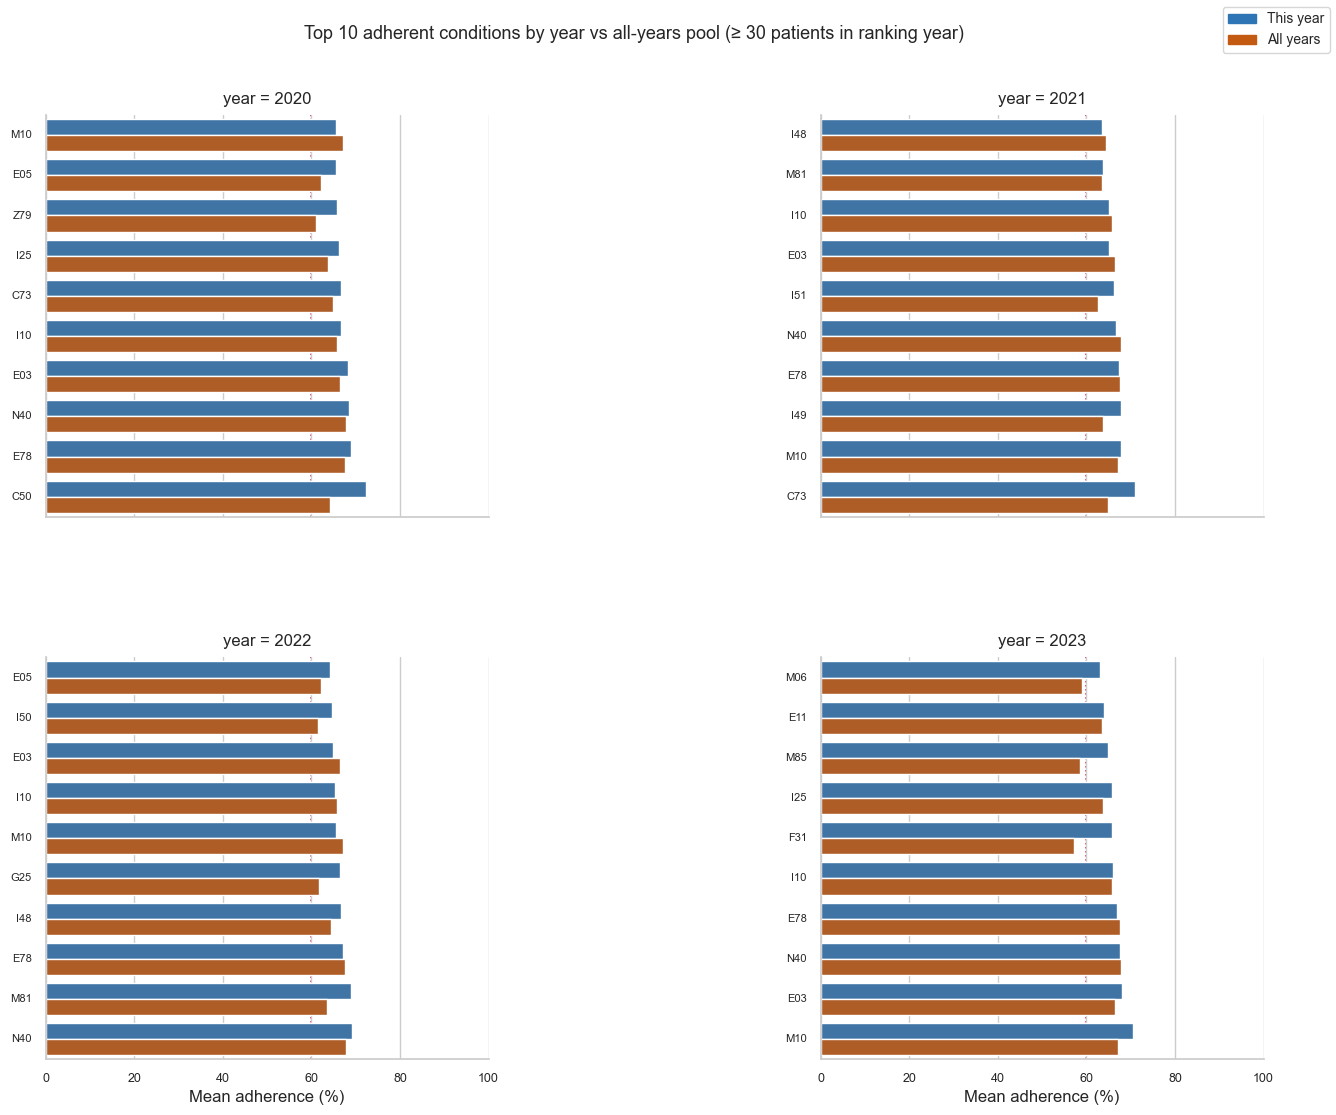


=== year = 2020 · top 10 ===


,condition,2020 %,n (2020),All years %,n (all),Δ (year − all)
0,C50,72.4,49,64.2,152,8.1
1,E78,68.9,2318,67.6,6035,1.4
2,N40,68.5,144,67.8,431,0.6
3,E03,68.2,566,66.4,1479,1.8
4,I10,66.7,3618,65.7,8566,0.9
5,C73,66.6,35,64.8,83,1.8
6,I25,66.2,308,63.7,721,2.5
7,Z79,65.7,155,61.0,446,4.8
8,E05,65.6,67,62.1,208,3.6
9,M10,65.6,180,67.1,402,-1.6



=== year = 2021 · top 10 ===


,condition,2021 %,n (2021),All years %,n (all),Δ (year − all)
10,C73,71.1,36,64.8,83,6.2
11,M10,67.9,190,67.1,402,0.8
12,I49,67.8,105,63.8,235,4.0
13,E78,67.4,2657,67.6,6035,-0.2
14,N40,66.6,186,67.8,431,-1.3
15,I51,66.1,68,62.7,158,3.4
16,E03,65.1,650,66.4,1479,-1.3
17,I10,65.0,3898,65.7,8566,-0.7
18,M81,63.7,77,63.6,167,0.1
19,I48,63.6,202,64.4,461,-0.8



=== year = 2022 · top 10 ===


,condition,2022 %,n (2022),All years %,n (all),Δ (year − all)
20,N40,69.1,157,67.8,431,1.3
21,M81,68.9,45,63.6,167,5.3
22,E78,67.1,2200,67.6,6035,-0.5
23,I48,66.6,151,64.4,461,2.2
24,G25,66.5,80,61.7,235,4.9
25,M10,65.7,134,67.1,402,-1.5
26,I10,65.2,3134,65.7,8566,-0.5
27,E03,65.0,527,66.4,1479,-1.4
28,I50,64.7,52,61.5,168,3.1
29,E05,64.1,79,62.1,208,2.0



=== year = 2023 · top 10 ===


,condition,2023 %,n (2023),All years %,n (all),Δ (year − all)
30,M10,70.5,100,67.1,402,3.4
31,E03,68.0,478,66.4,1479,1.5
32,N40,67.5,143,67.8,431,-0.3
33,E78,66.8,1900,67.6,6035,-0.8
34,I10,66.1,2505,65.7,8566,0.4
35,F31,65.8,83,57.2,305,8.6
36,I25,65.8,189,63.7,721,2.1
37,M85,64.9,39,58.5,123,6.4
38,E11,64.0,1259,63.6,3970,0.4
39,M06,63.1,101,58.9,278,4.1


In [ ]:
# --- 2×2 seaborn grid: each year's top-10 conditions vs all-years mean ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MIN_N = 30
TOP_N = 10

# Prefer in-memory pair_all; else reload parquet
if "pair_all" not in globals() or pair_all is None or pair_all.empty:
    tables_all, _ = all_years_output_dirs()
    pair_all = pd.read_parquet(tables_all / "model_df_pair_all_years.parquet")
    print(f"loaded pair_all from parquet ({len(pair_all):,} rows)")

cond = pair_all[["DUPERSID", "YEAR", "ICD10CDX", "meps_adherence_ratio"]].copy()
cond = cond.dropna(subset=["meps_adherence_ratio", "ICD10CDX"])

# ICD labels
label_src = None
for cand in (
    Path(REPO) / "Notebooks/MEPS/output/all_years/tables/patient_drug_condition_bridge.parquet",
    Path(REPO) / "Notebooks/MEPS/output/all_years/tables/new_grouped_merge_df_chronic_drugs.parquet",
):
    if cand.exists():
        lab = pd.read_parquet(cand, columns=["ICD10CDX", "ICD10CDX_LABEL"]).dropna()
        label_src = lab.drop_duplicates("ICD10CDX")
        break
if label_src is not None:
    cond = cond.merge(label_src, on="ICD10CDX", how="left")
else:
    cond["ICD10CDX_LABEL"] = cond["ICD10CDX"].astype(str)
def _wrap_two_lines(text: str, width: int = 28) -> str:
    """Wrap a label onto at most 2 lines for readable y-tick text."""
    words = str(text).split()
    if not words:
        return ""
    line1, line2 = [], []
    for w in words:
        trial = (" ".join(line1 + [w])).strip()
        if not line2 and len(trial) <= width:
            line1.append(w)
        else:
            line2.append(w)
    a = " ".join(line1)
    b = " ".join(line2)
    if len(b) > width:
        b = b[: max(0, width - 1)].rstrip() + "…"
    return a if not b else f"{a}\n{b}"


cond["condition"] = (
    cond["ICD10CDX_LABEL"]
    .fillna(cond["ICD10CDX"].astype(str))
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
    .map(lambda s: _wrap_two_lines(s, width=28))
)

# Per-year and all-years condition stats
by_year = (
    cond.groupby(["YEAR", "condition"], as_index=False)
    .agg(
        mean_adherence=("meps_adherence_ratio", "mean"),
        n_patients=("DUPERSID", "nunique"),
    )
)
all_yrs = (
    cond.groupby("condition", as_index=False)
    .agg(
        all_years=("meps_adherence_ratio", "mean"),
        n_all=("DUPERSID", "nunique"),
    )
)

# Drop conditions with < MIN_N patients *in that year*, then take top TOP_N per year
eligible = by_year[by_year["n_patients"] >= MIN_N].copy()
print(
    f"conditions with ≥ {MIN_N} patients (person–years): "
    f"{len(eligible):,} / {len(by_year):,} year–condition rows"
)
print("kept per year:")
print(eligible.groupby("YEAR").size().to_string())

top_rows = []
for y in YEARS:
    sub = (
        eligible[eligible["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)
        .head(TOP_N)
    )
    top_rows.append(sub)
top = pd.concat(top_rows, ignore_index=True)
top = top.merge(all_yrs, on="condition", how="left")

# Long form for seaborn: two bars per condition
# Build in rank order within each year so catplot x-axis follows top-10 rank
pieces = []
for y in YEARS:
    block = (
        top[top["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)
        .reset_index(drop=True)
    )
    block["rank"] = np.arange(1, len(block) + 1)
    pieces.append(block)
top_ordered = pd.concat(pieces, ignore_index=True)

long = pd.concat(
    [
        top_ordered.assign(metric="This year", value=top_ordered["mean_adherence"]),
        top_ordered.assign(metric="All years", value=top_ordered["all_years"]),
    ],
    ignore_index=True,
)
long["year"] = long["YEAR"].astype(int)

sns.set_theme(style="whitegrid", context="notebook")

# Horizontal bars: condition on y-axis so long ICD labels stay readable
g = sns.FacetGrid(
    long,
    col="year",
    col_order=YEARS,
    col_wrap=2,
    sharex=True,
    sharey=False,
    height=5.6,
    aspect=1.25,
)

def _draw_panel(data, color=None, **kwargs):
    ax = plt.gca()
    y = int(data["year"].iloc[0])
    # Highest adherence at top
    order = (
        data[data["metric"] == "This year"]
        .sort_values("rank", ascending=False)["condition"]
        .tolist()
    )
    sns.barplot(
        data=data,
        y="condition",
        x="value",
        hue="metric",
        order=order,
        hue_order=["This year", "All years"],
        palette={"This year": "#2e75b6", "All years": "#c45911"},
        ax=ax,
        errorbar=None,
        orient="h",
    )
    ax.set_title(f"year = {y}", fontsize=12, pad=8)
    ax.set_xlabel("Mean adherence (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.axvline(60, color="crimson", linestyle=":", linewidth=1.1, zorder=0)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=9)
    # Give wrapped 2-line y labels room; avoid clipping into the neighbor panel
    ax.tick_params(axis="y", pad=4)
    for lab in ax.get_yticklabels():
        lab.set_linespacing(0.95)
        lab.set_verticalalignment("center")
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

g.map_dataframe(_draw_panel)
g.fig.subplots_adjust(top=0.90, hspace=0.35, wspace=0.75, left=0.08, right=0.95)
g.fig.suptitle(
    f"Top {TOP_N} adherent conditions by year vs all-years pool "
    f"(≥ {MIN_N} patients in ranking year)",
    fontsize=13,
)

handles = [
    plt.Rectangle((0, 0), 1, 1, color="#2e75b6", label="This year"),
    plt.Rectangle((0, 0), 1, 1, color="#c45911", label="All years"),
]
g.fig.legend(handles=handles, loc="upper right", frameon=True, fontsize=10)
plt.show()

# Compact table: one block per year
for y in YEARS:
    block = (
        top[top["YEAR"] == y]
        .sort_values("mean_adherence", ascending=False)[
            ["condition", "mean_adherence", "n_patients", "all_years", "n_all"]
        ]
        .assign(delta=lambda d: d["mean_adherence"] - d["all_years"])
        .rename(
            columns={
                "mean_adherence": f"{y} %",
                "n_patients": f"n ({y})",
                "all_years": "All years %",
                "n_all": "n (all)",
                "delta": "Δ (year − all)",
            }
        )
    )
    print(f"\n=== year = {y} · top {len(block)} ===")
    display(block.round(1))


## Step L — Training frame

Drop identifiers and the continuous adherence ratio from `model_df_all` (keep `is_adherent` as the label).


In [ ]:
training_df = model_df_all.drop(
    columns=["DUPERSID", "YEAR", "meps_adherence_ratio"],
    errors="ignore",
).copy()

print(f"model_df_all: {model_df_all.shape[0]:,} rows × {model_df_all.shape[1]} cols")
print(f"training_df:  {training_df.shape[0]:,} rows × {training_df.shape[1]} cols")
print("dropped:", [c for c in ("DUPERSID", "YEAR", "meps_adherence_ratio") if c in model_df_all.columns])
training_df.head()


## Step M — Random Forest (`is_adherent`)

Same recipe as `2023_clean.ipynb`: `HalvingGridSearchCV` over the full RF grid, stratified 80/20 split, F1-tuned then AUC-tuned models. Features come from `training_df` (already dropped `DUPERSID` / `YEAR` / `meps_adherence_ratio`). Also drop `n_drugs` / `n_conditions` from **X** to match the 2023 baseline (label stays `is_adherent`).


In [ ]:
# ---- Modeling imports (same toolkit as 2023_clean) ----
from sklearn.ensemble import RandomForestClassifier
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    HalvingGridSearchCV, StratifiedKFold, train_test_split,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
)
import matplotlib.pyplot as plt
import time


def plot_cm_with_recall(cm, ax, title, labels=("not adherent", "adherent"), cmap="Blues"):
    """2x2 confusion matrix with row-normalized recall + accuracy in title."""
    cm = np.asarray(cm)
    row_totals = cm.sum(axis=1, keepdims=True)
    pct = np.divide(
        cm * 100.0, row_totals,
        out=np.zeros_like(cm, dtype=float),
        where=row_totals > 0,
    )
    acc = cm.trace() / cm.sum() * 100 if cm.sum() > 0 else 0.0

    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{title} (accuracy: {acc:.1f}%)")

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(
                j, i, f"{int(cm[i, j])}\n({pct[i, j]:.1f}%)",
                ha="center", va="center", color=color, fontsize=11,
            )
    return ax


print("RF modeling helpers ready")


In [ ]:
# Random Forest: predict is_adherent (hyperparameter tuning)
# Same PARAM_GRID / CV settings as 2023_clean.ipynb.

PARAM_GRID = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"],
}

CV_FOLDS = 5
SCORING = "f1"
TEST_SIZE = 0.2
RANDOM_STATE = 42

# training_df already dropped DUPERSID / YEAR / meps_adherence_ratio.
# Mirror 2023 baseline: also exclude count aggregates from X.
drop_from_X = ["is_adherent", "n_drugs", "n_conditions"]

X = training_df.drop(columns=[c for c in drop_from_X if c in training_df.columns]).copy()
y = training_df["is_adherent"].astype(int)

# AGE may be string ("unknown"); coerce for the forest
if "AGE" in X.columns:
    X["AGE"] = pd.to_numeric(X["AGE"], errors="coerce")

# RF needs numeric features only
non_num = X.select_dtypes(exclude=["number", "bool"]).columns.tolist()
if non_num:
    raise TypeError(f"Non-numeric columns still in X: {non_num}")

X = X.astype(np.float64)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"X shape: {X.shape} | train: {X_train.shape[0]} | test: {X_test.shape[0]}")
print(f"class balance (full):\n{y.value_counts(normalize=True).round(3)}")
print(
    f"GridSearch combos: {np.prod([len(v) for v in PARAM_GRID.values()])} "
    f"x {CV_FOLDS} folds"
)


In [ ]:
# HalvingGridSearchCV — F1-tuned (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="f1",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search.best_params_)
print(f"Best CV f1: {search.best_score_:.4f}")
print(
    f"Iterations run: {search.n_iterations_} | "
    f"n_candidates per iter: {search.n_candidates_} | "
    f"n_resources per iter: {search.n_resources_}"
)

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix (test set):")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
plot_cm_with_recall(cm, ax, "Random Forest (F1-tuned) — is_adherent")
plt.tight_layout()
plt.show()

best_params = {k: best_rf.get_params()[k] for k in PARAM_GRID if k in best_rf.get_params()}
best_score = float(search.best_score_)


In [ ]:
# HalvingGridSearchCV — AUC-tuned (same settings as 2023_clean)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
search_auc = HalvingGridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=PARAM_GRID,
    scoring="roc_auc",
    cv=cv,
    factor=3,
    resource="n_samples",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
search_auc.fit(X_train, y_train)
print(f"\nDone in {(time.perf_counter() - t0) / 60:.1f} minutes")
print("Best params:", search_auc.best_params_)
print(f"Best CV roc_auc: {search_auc.best_score_:.4f}")
print(
    f"Iterations run: {search_auc.n_iterations_} | "
    f"n_candidates per iter: {search_auc.n_candidates_} | "
    f"n_resources per iter: {search_auc.n_resources_}"
)

best_rf_auc = search_auc.best_estimator_
y_pred_auc = best_rf_auc.predict(X_test)
y_proba_auc = best_rf_auc.predict_proba(X_test)[:, 1]

print(f"\nTest ROC-AUC: {roc_auc_score(y_test, y_proba_auc):.4f}")
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_auc, digits=3))

cm_auc = confusion_matrix(y_test, y_pred_auc)
print("Confusion matrix (test set):")
print(cm_auc)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm_with_recall(cm_auc, axes[0], "Random Forest (AUC-tuned) — confusion matrix")
RocCurveDisplay.from_predictions(y_test, y_proba_auc, ax=axes[1])
axes[1].set_title("Random Forest (AUC-tuned) — ROC curve")
plt.tight_layout()
plt.show()

best_params_auc = {
    k: best_rf_auc.get_params()[k] for k in PARAM_GRID if k in best_rf_auc.get_params()
}
best_score_auc = float(search_auc.best_score_)


In [ ]:
# Feature importance (Gini) — prefer AUC-tuned model when available

model_for_imp = best_rf_auc if "best_rf_auc" in dir() else best_rf
model_label = (
    "AUC-tuned"
    if "best_rf_auc" in dir() and model_for_imp is best_rf_auc
    else "F1-tuned"
)

TOP_N = 20

gini_imp = (
    pd.Series(model_for_imp.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(f"Gini importance — top {TOP_N} ({model_label} RF)")
display(gini_imp.head(TOP_N).to_frame("gini_importance"))

fig, ax = plt.subplots(figsize=(8, 6))
gini_imp.head(TOP_N).iloc[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Gini importance (mean decrease in impurity)")
ax.set_title(f"Top {TOP_N} features — Gini ({model_label})")
plt.tight_layout()
plt.show()


In [ ]:
# Predict is_adherent on holdout (or any feature frame with the same columns)

def predict_adherence(features: pd.DataFrame, model=None, threshold: float = 0.5):
    """Return predicted label + P(adherent) using the tuned RF.

    ``features`` must include the same columns as ``X_train`` (extra columns
    are ignored; missing columns raise).
    """
    model = model or (best_rf_auc if "best_rf_auc" in dir() else best_rf)
    cols = list(X_train.columns)
    missing = [c for c in cols if c not in features.columns]
    if missing:
        raise KeyError(f"Missing feature columns: {missing[:10]}{'...' if len(missing) > 10 else ''}")
    X_new = features[cols].copy()
    if "AGE" in X_new.columns:
        X_new["AGE"] = pd.to_numeric(X_new["AGE"], errors="coerce")
    X_new = X_new.astype(np.float64).fillna(X_train.median(numeric_only=True))
    proba = model.predict_proba(X_new)[:, 1]
    pred = (proba >= threshold).astype(int)
    return pd.DataFrame({"is_adherent_pred": pred, "p_adherent": proba}, index=features.index)


# Demo on the held-out test set
pred_test = predict_adherence(X_test)
pred_test["is_adherent_true"] = y_test.to_numpy()
print(pred_test.head(10))
print(
    "\nHoldout accuracy:",
    float((pred_test["is_adherent_pred"] == pred_test["is_adherent_true"]).mean()),
)
